# 文件: chart_13_1.py

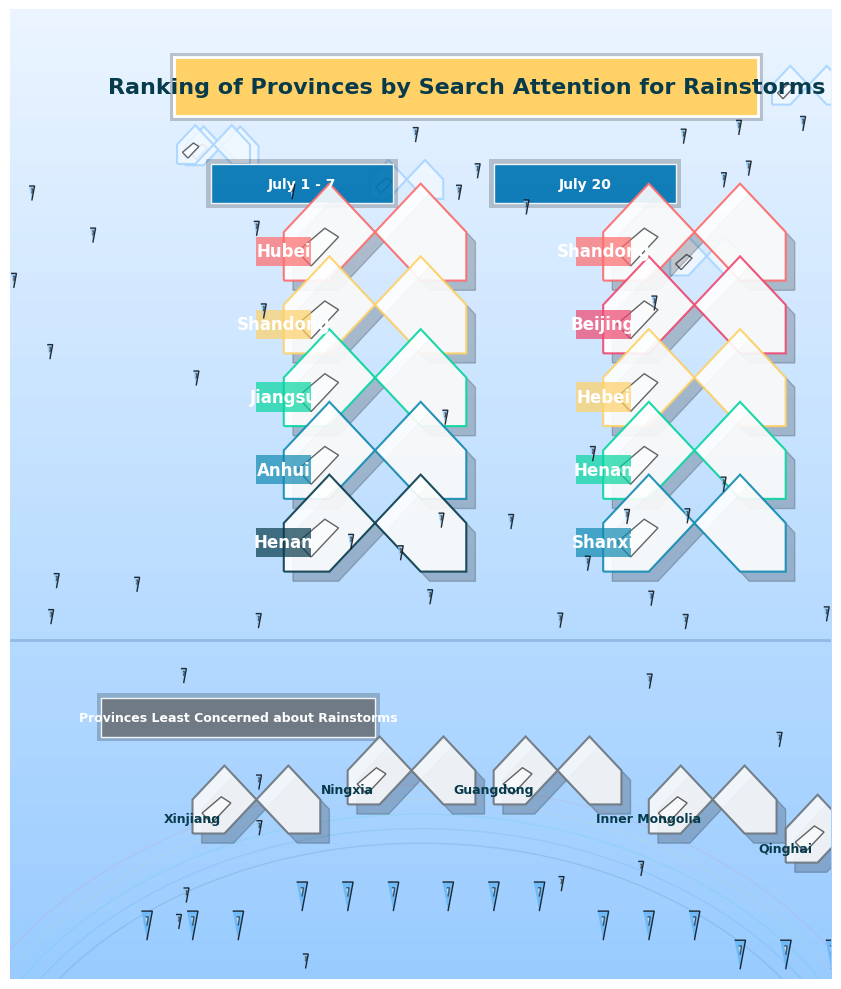

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, PathPatch, Path, Rectangle, Circle
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Definir la función para dibujar la forma de una nube (versión mejorada)
def draw_cloud(ax, x, y, scale=1, color='#ffffff', edge_color='#a8d5ff', shadow=True):
    """Dibujar la forma de una nube con efecto tridimensional"""
    # Nube principal
    verts = [
        (0, 0), (1, 0), (2, 1), (3, 0), (4, 0),
        (4, 1), (3, 2), (2, 1), (1, 2), (0, 1),
        (0, 0)
    ]
    verts = np.array(verts) * scale + [x, y]
    path = Path(verts)

    # Agregar efecto de sombra
    if shadow:
        shadow_verts = verts + [0.1, -0.1]
        shadow_path = Path(shadow_verts)
        shadow_patch = PathPatch(shadow_path, facecolor='black', alpha=0.2)
        ax.add_patch(shadow_patch)

    patch = PathPatch(path, facecolor=color, edgecolor=edge_color, linewidth=1.5, alpha=0.9)
    ax.add_artist(patch)

    # Agregar brillo
    highlight_verts = [
        (1, 0.5), (2, 1.5), (1.5, 1.8), (0.5, 1), (1, 0.5)
    ]
    highlight_verts = np.array(highlight_verts) * scale * 0.6 + [x, y]
    highlight_path = Path(highlight_verts)
    highlight_patch = PathPatch(highlight_path, facecolor='white', alpha=0.6)
    ax.add_artist(highlight_patch)

    return patch

# Definir la función para dibujar la forma de una gota de lluvia (versión mejorada)
def draw_rain(ax, x, y, num_drops=3, scale=1, color='#64b5f6'):
    """Dibujar gotas de lluvia con efecto de degradado"""
    drop_verts = [(-0.2, 0), (0.2, 0), (0, -1)]
    drop_verts = np.array(drop_verts) * scale

    for i in range(num_drops):
        dx = (i - (num_drops - 1) / 2) * 0.5
        drop_path = Path(drop_verts + [x + dx, y - 0.5])

        # Crear efecto de degradado
        drop_patch = PathPatch(drop_path, facecolor=color, alpha=0.8)
        ax.add_artist(drop_patch)

        # Agregar brillo a la gota de lluvia
        highlight_verts = [(-0.05, -0.2), (0.05, -0.2), (0, -0.5)]
        highlight_verts = np.array(highlight_verts) * scale
        highlight_path = Path(highlight_verts + [x + dx, y - 0.5])
        highlight_patch = PathPatch(highlight_path, facecolor='white', alpha=0.6)
        ax.add_artist(highlight_patch)

# Definir la función para dibujar el efecto del arcoíris
def draw_rainbow(ax, x, y, width, height):
    """Dibujar el efecto del arcoíris de fondo"""
    colors = ['#ff6b6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c']
    for i, color in enumerate(colors):
        arc = Arc((x, y), width - i * 0.3, height - i * 0.3,
                  theta1=0, theta2=180, color=color, alpha=0.1)
        ax.add_artist(arc)

# Crear el lienzo y agregar el fondo degradado
fig, ax = plt.subplots(figsize=(9, 10))  # Aumentar ligeramente el ancho del lienzo
ax.set_xlim(0, 9)  # Ajustar el rango del eje x
ax.set_ylim(0, 10)
ax.axis('off')

# Crear el fondo degradado
x = np.linspace(0, 9, 100)
y = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x, y)
Z = Y

cmap = LinearSegmentedColormap.from_list('sky_gradient', ['#e6f2ff', '#b3d9ff', '#80bfff'])
im = ax.imshow(Z, cmap=cmap, extent=[0, 9, 0, 10], alpha=0.8, aspect='auto')

# Agregar el arcoíris de fondo
draw_rainbow(ax, 4.5, -2, 11, 8)  # Ajustar la posición del arcoíris para adaptarse al nuevo lienzo

# Dibujar nubes decorativas pequeñas
for i in range(5):
    x_pos = np.random.uniform(0.5, 8.5)  # Adaptarse al nuevo rango del eje x
    y_pos = np.random.uniform(7, 9.5)
    draw_cloud(ax, x_pos, y_pos, scale=0.2, color='#f0f8ff', shadow=False)

# Dibujar el área del título (aumentar立体感)
title_rect_bg = Rectangle((1.75, 8.85), 6.5, 0.7, facecolor='black', alpha=0.2)  # Aumentar el ancho del fondo del título
ax.add_artist(title_rect_bg)
title_rect = Rectangle((1.8, 8.9), 6.4, 0.6, facecolor='#ffd166', edgecolor='white', linewidth=2)  # Aumentar el ancho del marco del título
ax.add_artist(title_rect)
ax.text(5, 9.2, 'Clasificación de las provincias por la atención de búsqueda de tormentas', 
        fontsize=16, color='#073b4c',  # Disminuir el tamaño de la fuente
        ha='center', va='center', fontweight='bold')

# Dibujar los títulos de los dos períodos de tiempo (agregar esquinas redondeadas y立体感)
def draw_fancy_rect(ax, x, y, width, height, color, text, font_size=10):
    """Dibujar un título rectangular con esquinas redondeadas y立体感"""
    rect_bg = Rectangle((x - 0.05, y - 0.05), width + 0.1, height + 0.1,
                        facecolor='black', alpha=0.2, edgecolor='none')
    ax.add_artist(rect_bg)

    rect = Rectangle((x, y), width, height, facecolor=color,
                     edgecolor='white', linewidth=1, alpha=0.9)
    ax.add_artist(rect)

    ax.text(x + width / 2, y + height / 2, text, fontsize=font_size,
            color='white', ha='center', va='center', fontweight='bold')

draw_fancy_rect(ax, 2.2, 8.0, 2, 0.4, '#0077b6', '1 - 7 de julio')
draw_fancy_rect(ax, 5.3, 8.0, 2, 0.4, '#0077b6', '20 de julio')  # Ajustar la posición

# Dibujar la línea de separación
divider = plt.Line2D([0, 9], [3.5, 3.5], color='#003e7e', alpha=0.2, linewidth=2)  # Adaptarse al nuevo eje x
ax.add_artist(divider)

# Dibujar las nubes de las provincias del 1 - 7 de julio (agregar colores degradados)
period1_provinces = ['Hubei', 'Shandong', 'Jiangsu', 'Anhui', 'Henan']
period1_colors = ['#ff6b6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c']
y_pos1 = np.linspace(7.2, 4.2, 5)

for i, (prov, color) in enumerate(zip(period1_provinces, period1_colors)):
    draw_cloud(ax, 3, y_pos1[i], scale=0.5, color='#ffffff', edge_color=color)
    # Agregar el fondo del nombre de la provincia
    name_bg = Rectangle((2.7, y_pos1[i] + 0.15), 0.6, 0.3, facecolor=color, alpha=0.7, edgecolor='none')
    ax.add_artist(name_bg)
    ax.text(3, y_pos1[i] + 0.3, prov, fontsize=12, color='white',
            ha='center', va='center', fontweight='bold')

# Dibujar las nubes de las provincias del 20 de julio (agregar colores degradados)
period2_provinces = ['Shandong', 'Beijing', 'Hebei', 'Henan', 'Shanxi']
period2_colors = ['#ff6b6b', '#ef476f', '#ffd166', '#06d6a0', '#118ab2']
y_pos2 = np.linspace(7.2, 4.2, 5)

for i, (prov, color) in enumerate(zip(period2_provinces, period2_colors)):
    draw_cloud(ax, 6.5, y_pos2[i], scale=0.5, color='#ffffff', edge_color=color)  # Ajustar la posición x
    # Agregar el fondo del nombre de la provincia
    name_bg = Rectangle((6.2, y_pos2[i] + 0.15), 0.6, 0.3, facecolor=color, alpha=0.7, edgecolor='none')  # Ajustar la posición
    ax.add_artist(name_bg)
    ax.text(6.5, y_pos2[i] + 0.3, prov, fontsize=12, color='white',  # Ajustar la posición
            ha='center', va='center', fontweight='bold')

# Dibujar el título "provincias menos preocupadas por las tormentas"
draw_fancy_rect(ax, 1, 2.5, 3, 0.4, '#6c757d', 'Provincias menos preocupadas por las tormentas', font_size=9)  # Aumentar el ancho y disminuir el tamaño de la fuente

# Dibujar las provincias menos preocupadas (con gotas de lluvia)
least_provinces = [('Xinjiang', 2, 1.5, 3), ('Ningxia', 3.7, 1.8, 3),
                   ('Guangdong', 5.3, 1.8, 3), ('Inner Mongolia', 7, 1.5, 3), ('Qinghai', 8.5, 1.2, 3)]  # Ajustar la posición para adaptarse al nuevo lienzo

for i, (prov, x, y, drops) in enumerate(least_provinces):
    draw_cloud(ax, x, y, scale=0.35, color='#f8f9fa', edge_color='#6c757d')
    # Agregar el nombre de la provincia
    ax.text(x, y + 0.15, prov, fontsize=9, color='#073b4c',  # Disminuir el tamaño de la fuente
            ha='center', va='center', fontweight='bold')
    # Agregar gotas de lluvia
    draw_rain(ax, x, y - 0.3, num_drops=drops, scale=0.3, color='#64b5f6')

# Agregar gotas de lluvia decorativas de fondo
for _ in range(50):
    x_pos = np.random.uniform(0, 9)  # Adaptarse al nuevo eje x
    y_pos = np.random.uniform(0, 10)
    draw_rain(ax, x_pos, y_pos, num_drops=1, scale=0.15, color='#90caf9')

plt.tight_layout()
plt.show()

# 文件: chart_13_2.py

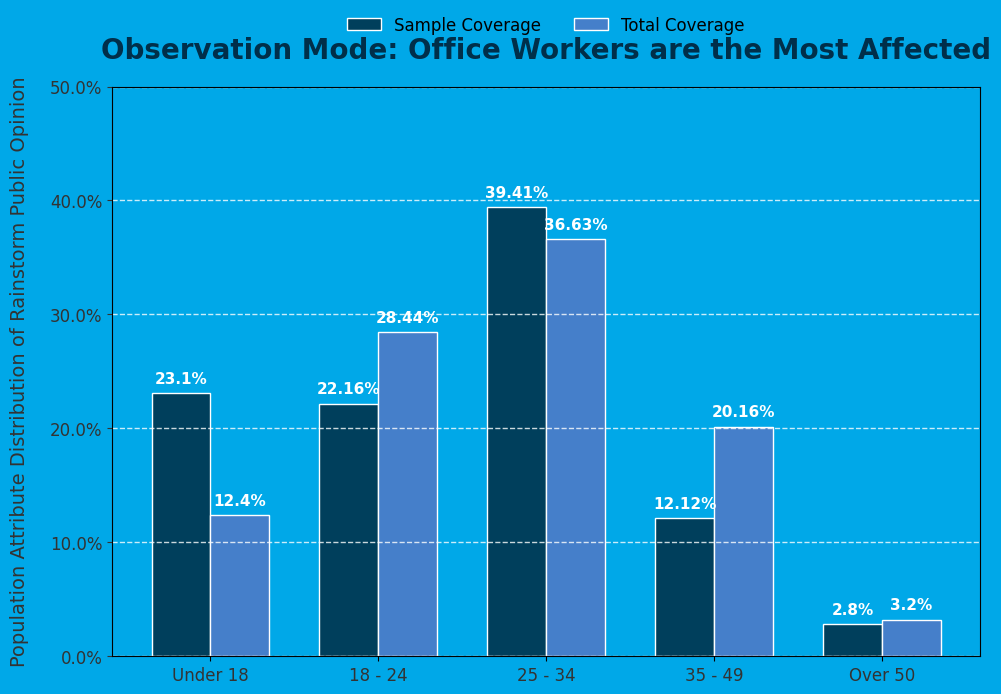

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Organize data
age_groups = ["Under 18", "18 - 24", "25 - 34", "35 - 49", "Over 50"]
sample_coverage = [23.1, 22.16, 39.41, 12.12, 2.8]  # Sample coverage data
total_coverage = [12.4, 28.44, 36.63, 20.16, 3.2]  # Total coverage data

x = np.arange(len(age_groups))  # x-axis tick positions
width = 0.35  # Bar width

# Create a figure and a subplot, optimize the figure size for adaptation
fig, ax = plt.subplots(figsize=(10, 7))
# Set the overall background color, similar to the blue in the original figure
fig.set_facecolor('#00a8e8')
ax.set_facecolor('#00a8e8')

# Draw the sample coverage bar chart, adjust the color to be softer
rects1 = ax.bar(
    x - width/2, 
    sample_coverage, 
    width, 
    label='Sample Coverage', 
    color='#003f5c',
    edgecolor='white',  # Add white strokes to distinguish columns
    linewidth=1
)
# Draw the total coverage bar chart, adjust the color to be softer
rects2 = ax.bar(
    x + width/2, 
    total_coverage, 
    width, 
    label='Total Coverage', 
    color='#457fca',
    edgecolor='white',  # Add white strokes to distinguish columns
    linewidth=1
)

# Customize the title style
ax.set_title(
    'Observation Mode: Office Workers are the Most Affected', 
    fontsize=20, 
    fontweight='bold', 
    color='#002f4a',  # Darker title for better visibility
    pad=20  # Increase the spacing between the title and the chart
)
ax.set_ylabel(
    'Population Attribute Distribution of Rainstorm Public Opinion', 
    fontsize=14, 
    color='#333333',
    labelpad=15  # Increase the spacing between the y-axis label and the chart
)

# Customize the x-axis tick label style
ax.set_xticks(x)
ax.set_xticklabels(
    age_groups, 
    fontsize=12, 
    color='#333333',
    rotation=0  # Keep horizontal display
)

# Optimize the y-axis scale, display percentages more clearly
ax.set_ylim(0, 50)  # Set a reasonable y-axis range
ax.yaxis.set_major_formatter('{x}%')  # Directly display the percentage style (requires matplotlib 3.3+)
ax.tick_params(axis='y', labelsize=12, colors='#333333')

# Optimize the data label style
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height}%',
            xy=(rect.get_x() + rect.get_width()/2, height),
            xytext=(0, 5),  # Adjust the label position to avoid occlusion
            textcoords='offset points',
            ha='center', 
            va='bottom',
            fontsize=11,
            color='white',  # White labels are more eye-catching
            fontweight='bold'
        )

autolabel(rects1)
autolabel(rects2)

# Customize the legend style, place it above the chart
legend_elements = [
    Patch(facecolor='#003f5c', edgecolor='white', label='Sample Coverage'),
    Patch(facecolor='#457fca', edgecolor='white', label='Total Coverage')
]
ax.legend(
    handles=legend_elements,
    loc='upper center',  # Legend position
    bbox_to_anchor=(0.5, 1.15),  # Fine-tune the legend position above the chart
    ncol=2,  # Display the legend in two columns
    fontsize=12,
    frameon=False  # Remove the legend border
)

# Add gridlines to enhance readability
ax.grid(
    axis='y', 
    color='white', 
    linestyle='--', 
    alpha=0.8,
    linewidth=1
)

# Optimize the overall layout
plt.tight_layout()
# Display the chart
plt.show()

# 文件: chart_13_3.py

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_44620\331268428.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues', 12)


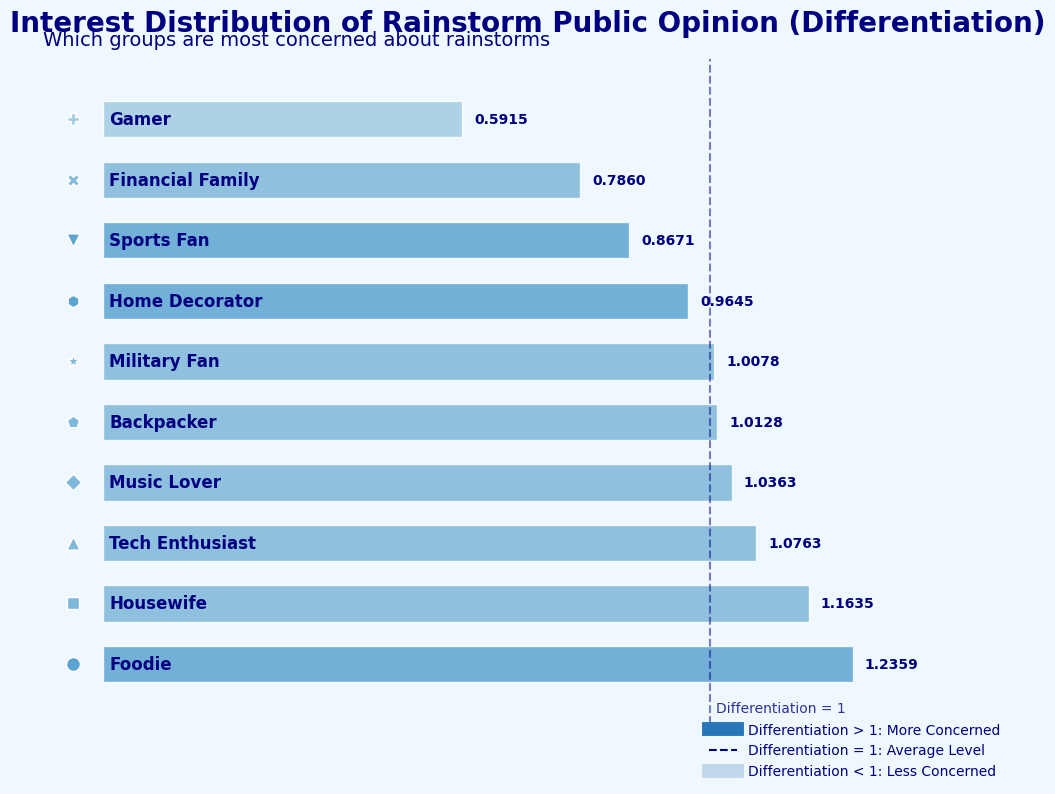

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Data
groups = ["Foodie", "Housewife", "Tech Enthusiast", "Music Lover", "Backpacker", 
          "Military Fan", "Home Decorator", "Sports Fan", "Financial Family", "Gamer"]
values = [1.2359, 1.1635, 1.0763, 1.0363, 1.0128, 
          1.0078, 0.9645, 0.8671, 0.7860, 0.5915]

# Symbol mapping (built - in markers in matplotlib)
markers = ['o', 's', '^', 'D', 'p', '*', 'h', 'v', 'X', 'P']
marker_sizes = [100, 80, 90, 70, 85, 95, 80, 90, 75, 85]

# Create a canvas
fig, ax = plt.subplots(figsize=(10, 8), facecolor="#f0f8ff")
ax.set_facecolor("#f0f8ff")

# Draw a bar chart (using gradient colors)
cmap = plt.cm.get_cmap('Blues', 12)
for i, (value, group) in enumerate(zip(values, groups)):
    color_idx = int(value * 5) if value > 1 else int(value * 5) + 2
    color = cmap(color_idx)
    
    ax.barh(i, value, height=0.6, color=color, edgecolor='white', alpha=0.85)
    ax.text(value + 0.02, i, f"{value:.4f}", 
            ha="left", va="center", color='navy', fontsize=10, fontweight='bold')

# Set the title
ax.set_title("Interest Distribution of Rainstorm Public Opinion (Differentiation)", 
             fontdict={"fontsize":20, "fontweight":"bold", "color":"navy"},
             pad=20)
ax.text(0, 1.02, "Which groups are most concerned about rainstorms", 
        transform=ax.transAxes, fontsize=14, color='navy')

# Add symbols and category labels
for i, (group, marker, size) in enumerate(zip(groups, markers, marker_sizes)):
    color_idx = int(values[i] * 5) if values[i] > 1 else int(values[i] * 5) + 2
    color = cmap(color_idx)
    
    ax.scatter(-0.05, i, marker=marker, s=size, color=color, edgecolor='white', zorder=3)
    ax.text(0.01, i, group, fontsize=12, ha="left", va="center", 
            color='navy', fontweight='bold')

# Add a reference line (Differentiation = 1)
ax.axvline(x=1, color='navy', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(1.01, -0.8, "Differentiation = 1", fontsize=10, color='navy', alpha=0.8)

# Hide the axes
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Set the x - axis range
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(-1, 10)

# Add a legend (move it down)
legend_elements = [
    Line2D([0], [0], color=cmap(8), lw=10, label='Differentiation > 1: More Concerned'),
    Line2D([0], [0], color='navy', linestyle='--', lw=1.5, label='Differentiation = 1: Average Level'),
    Line2D([0], [0], color=cmap(3), lw=10, label='Differentiation < 1: Less Concerned')
]
ax.legend(handles=legend_elements, 
          loc='lower right',  # Position it in the lower right corner
          bbox_to_anchor=(1, -0.1),  # Move it down by 10% of the height
          frameon=False, 
          fontsize=10, 
          labelcolor='navy')

# Add grid lines
ax.grid(axis='x', linestyle='--', alpha=0.3, color='lightblue')

plt.tight_layout()
plt.show()

# 文件: chart_13_4.py

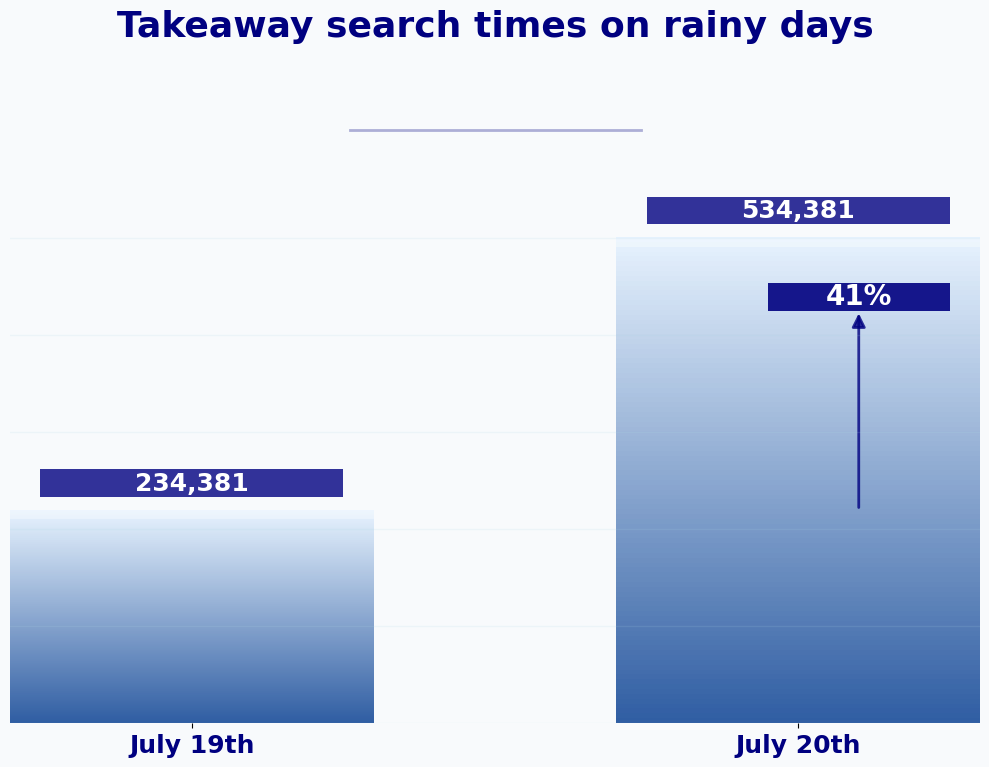

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.font_manager as fm

# Data
dates = ["July 19th", "July 20th"]
searches = [234381, 534381]
increase = 41  # Growth rate

# Create a custom gradient color
colors = [(0.9, 0.95, 1), (0.1, 0.3, 0.6)]  # From light blue to dark blue
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors, N=100)

# Create a canvas
fig, ax = plt.subplots(figsize=(10, 8), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")

# Draw the background grid
for y in np.linspace(0, max(searches), 6):
    ax.axhline(y, color='lightblue', alpha=0.15, linewidth=1)

# Draw a bar chart (with a three - dimensional effect)
x_pos = np.arange(len(dates))
bar_width = 0.6

for i, (date, search) in enumerate(zip(dates, searches)):
    # Main bar chart (gradient fill)
    rect = Rectangle((i - bar_width/2, 0), bar_width, search, 
                    facecolor='none', edgecolor='none')
    ax.add_patch(rect)
    
    img = np.ones((100, 1)) * np.linspace(0.3, 1, 100).reshape(-1, 1)
    ax.imshow(img, aspect='auto', extent=[i - bar_width/2, i + bar_width/2, 0, search],
              cmap=custom_cmap, alpha=0.9, clip_path=rect)
    
    # Top highlight
    top_highlight = Rectangle((i - bar_width/2, search - 10000), bar_width, 10000, 
                             facecolor='white', alpha=0.3)
    ax.add_patch(top_highlight)
    
    # Numerical label (with shadow effect)
    label_bg = Rectangle((i - 0.25, search + 15000), 0.5, 30000, 
                        facecolor='navy', alpha=0.8, zorder=3)
    ax.add_patch(label_bg)
    
    ax.text(i, search + 30000, f'{search:,}', 
            ha='center', va='center', color='white', fontsize=18, 
            fontweight='bold', zorder=4)

# Add growth rate indication (using arrows and percentage signs)
class CustomArrow(FancyArrowPatch):
    def __init__(self, posA, posB, **kwargs):
        super().__init__(posA, posB, arrowstyle='-|>', 
                         mutation_scale=20, **kwargs)

arrow = CustomArrow((1.1, searches[0]), (1.1, searches[1]*0.85), 
                   color='navy', alpha=0.8, linewidth=2)
ax.add_patch(arrow)

# Growth rate percentage marker
growth_bg = Rectangle((1.1 - 0.15, searches[1]*0.85), 0.3, 30000, 
                     facecolor='navy', alpha=0.9, zorder=3)
ax.add_patch(growth_bg)

ax.text(1.1, searches[1]*0.85 + 15000, f'{increase}%', 
        ha='center', va='center', color='white', fontsize=20, 
        fontweight='bold', zorder=4)

# Set the title (with decorative lines)
title = ax.set_title('Takeaway search times on rainy days', 
                     fontdict={'fontsize':26, 'fontweight':'bold', 'color':'navy'},
                     pad=40, loc='center')

# Decorative line under the title
line_start = 0.35
line_end = 0.65
ax.plot([line_start, line_end], [0.94, 0.94], transform=ax.transAxes, 
        color='navy', alpha=0.3, linewidth=2)

# Hide the axes
ax.set_xticks(x_pos)
ax.set_xticklabels(dates, color='navy', fontsize=18, fontweight='bold')
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Set the y - axis range
ax.set_ylim(0, max(searches) * 1.3)

# Add a bottom decorative bar
bottom_bar = Rectangle((-0.5, -30000), 2.5, 30000, 
                      facecolor='navy', alpha=0.1)
ax.add_patch(bottom_bar)

# Optimize the layout
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Make space for the title
plt.show()